# 測試 TensorFlow YOLO4 格式檔

In [1]:
# 載入套件
import time
from absl import app, flags, logging
from absl.flags import FLAGS
from PIL import Image
import cv2
import numpy as np
import tensorflow as tf
import os
import sys
directory_path = os.path.abspath(os.path.join('YOLO4'))
if directory_path not in sys.path:
    sys.path.append(directory_path)
import YOLO4.core.utils as utils
from YOLO4.core.yolov4 import YOLOv4, YOLOv3, YOLOv3_tiny, decode

In [2]:
# 設定 YOLO 模型參數
STRIDES = np.array([8, 16, 32])
ANCHORS = utils.get_anchors("./YOLO4/data/anchors/yolov4_anchors.txt", False)
NUM_CLASS = len(utils.read_class_names("./YOLO4/data/classes/coco.names"))
XYSCALE = [1.2, 1.1, 1.05]  # 縮放比例
input_size = 608
yolov4_weights_path = "./YOLO_weights/yolov4.weights"

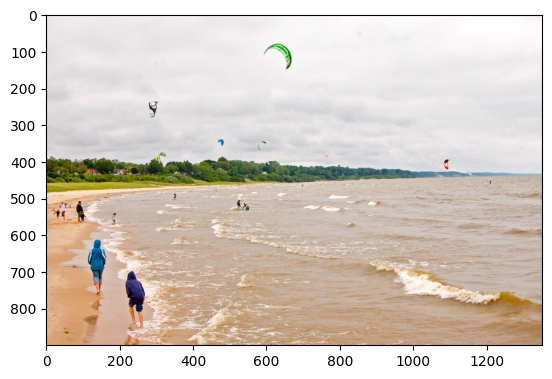

In [3]:
# 讀取測試影像
import matplotlib.pyplot as plt
image_path = './YOLO4/data/kite.jpg'
original_image = cv2.imread(image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
original_image_size = original_image.shape[:2]
plt.imshow(original_image)

# 前置處理
image_data = utils.image_preporcess(np.copy(original_image), 
                                    [input_size, input_size])
image_data = image_data[np.newaxis, ...].astype(float)

In [4]:
# 結合模型結構與權重檔，建立模型
input_layer = tf.keras.layers.Input([input_size, input_size, 3])
feature_maps = YOLOv4(input_layer, NUM_CLASS)
bbox_tensors = []
for i, fm in enumerate(feature_maps):
    bbox_tensor = decode(fm, NUM_CLASS, i)
    bbox_tensors.append(bbox_tensor)
# 模型結構    
model = tf.keras.Model(input_layer, bbox_tensors)

# 載入權重
utils.load_weights(model, yolov4_weights_path)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 608, 608, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 608, 608, 32)         864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 608, 608, 32)         128       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 lambda (Lambda)             (None, 608, 608, 32)         0         ['batch_normalization[0][0

In [5]:
# 預測
pred_bbox = model.predict(image_data)

# 找出 Bounding Box
pred_bbox = utils.postprocess_bbbox(pred_bbox, ANCHORS, STRIDES, XYSCALE)
bboxes = utils.postprocess_boxes(pred_bbox, original_image_size, input_size, 0.25)

# 使用NMS，移除重疊的 Bounding Box
bboxes = utils.nms(bboxes, 0.213, method='nms')

# 原圖加框
image = utils.draw_bbox(original_image, bboxes)
image = Image.fromarray(image)

# 顯示結果
plt.imshow(image)
image.show()

1/1 [==============================] - 2s 2s/step


AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations